<a href="https://colab.research.google.com/github/kuttybayguldana/2gis/blob/main/2gis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests pandas matplotlib seaborn

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
API_KEY = "db30f680-a5a3-4269-8a82-f1dad8c121a6"

In [27]:
url = "https://catalog.api.2gis.com/3.0/items"

params = {
    "q": "кафе",
    "location": "76.889709,43.238949",  # центр Алматы
    "radius": 5000,
    "page_size": 10,
    "key": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data['result']['items'])
df.to_csv('almaty_cafes.csv', index=False)
df.head()


,address_name,id,name,type,address_comment,full_name,purpose_name
0,"проспект Абая, 159Б",70000001038081997,"Selfie, лаундж-бар",branch,NaN,NaN,NaN
1,"улица Розыбакиева, 77",9429940001348242,"Chechil, пивной ресторан",branch,цокольный этаж,NaN,NaN
2,"улица Умурзакова, 76",70000001075065949,"Ololo, лаундж-бар",branch,NaN,NaN,NaN
3,"улица Шакарима, 12",70000001114128649,"lagmanchi_mekhrishat, кафе",branch,NaN,"Алматы, улица Шакарима, 12","Кафе, бар"
4,"проспект Абая, 143",70000001050204808,"Coffee Shake, кофейня",branch,1 этаж,NaN,NaN


In [15]:
df = pd.DataFrame(all_items)
df

,address_name,id,name,type,address_comment,full_name,purpose_name
0,"проспект Абая, 159Б",70000001038081997,"Selfie, лаундж-бар",branch,NaN,NaN,NaN
1,"улица Розыбакиева, 77",9429940001348242,"Chechil, пивной ресторан",branch,цокольный этаж,NaN,NaN
2,"улица Умурзакова, 76",70000001075065949,"Ololo, лаундж-бар",branch,NaN,NaN,NaN
3,"улица Шакарима, 12",70000001114128649,"lagmanchi_mekhrishat, кафе",branch,NaN,"Алматы, улица Шакарима, 12","Кафе, бар"
4,"проспект Абая, 143",70000001050204808,"Coffee Shake, кофейня",branch,1 этаж,NaN,NaN
5,"Хусаинова улица, 40",9429940001199598,"Asian BarBeQue, кафе корейской кухни",branch,2 этаж,NaN,NaN
6,"проспект Гагарина, 92",70000001029793290,"Пятница, кафе-бар",branch,NaN,"Алматы, проспект Гагарина, 92 / улица Курманга...","Кафе, бар"
7,"улица Розыбакиева, 140",9429940000918727,"Adal, кафе",branch,1 этаж,NaN,NaN
8,"проспект Абая, 143",70000001099729499,"Veselidze Resto Bar & Karaoke, кафе",branch,1 этаж,NaN,NaN
9,"улица Розыбакиева, 33Б",70000001056395205,"Кульджа Хого, кафе",branch,1 этаж,NaN,NaN


In [30]:
print(df.columns.tolist())  # какие столбцы есть
print(df.shape)              # сколько строк и столбцов
df.isnull().sum()            # сколько пропусков в каждом столбце

['address_name', 'id', 'name', 'type', 'address_comment', 'full_name', 'purpose_name']
(10, 7)


,0
address_name,0
id,0
name,0
type,0
address_comment,4
full_name,8
purpose_name,0


In [28]:
df = df.copy()
df['purpose_name'] = df['purpose_name'].fillna('Не указано')

In [19]:
def get_category(name):
    name = name.lower()
    if 'ресторан' in name:
        return 'Ресторан'
    elif 'кофейня' in name or 'coffee' in name:
        return 'Кофейня'
    elif 'бар' in name:
        return 'Бар'
    elif 'кафе' in name:
        return 'Кафе'
    elif 'чайхана' in name:
        return 'Чайхана'
    else:
        return 'Другое'

df['category'] = df['name'].apply(get_category)
df['category'].value_counts()

,count
category,
Кафе,28
Бар,10
Ресторан,4
Кофейня,3
Другое,3
Чайхана,2


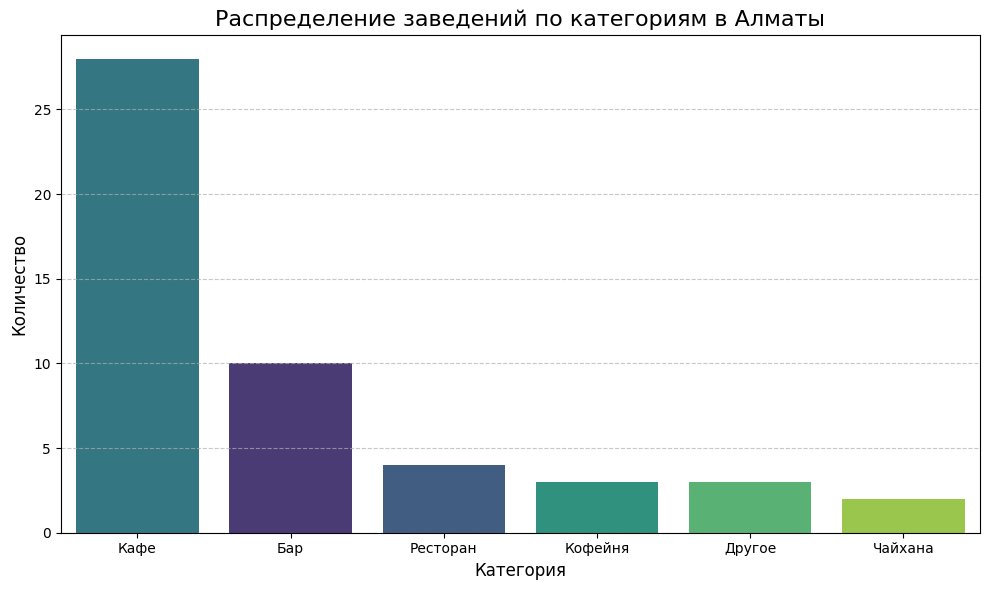

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', hue='category', order=df['category'].value_counts().index, palette='viridis', legend=False)
plt.title('Распределение заведений по категориям в Алматы', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

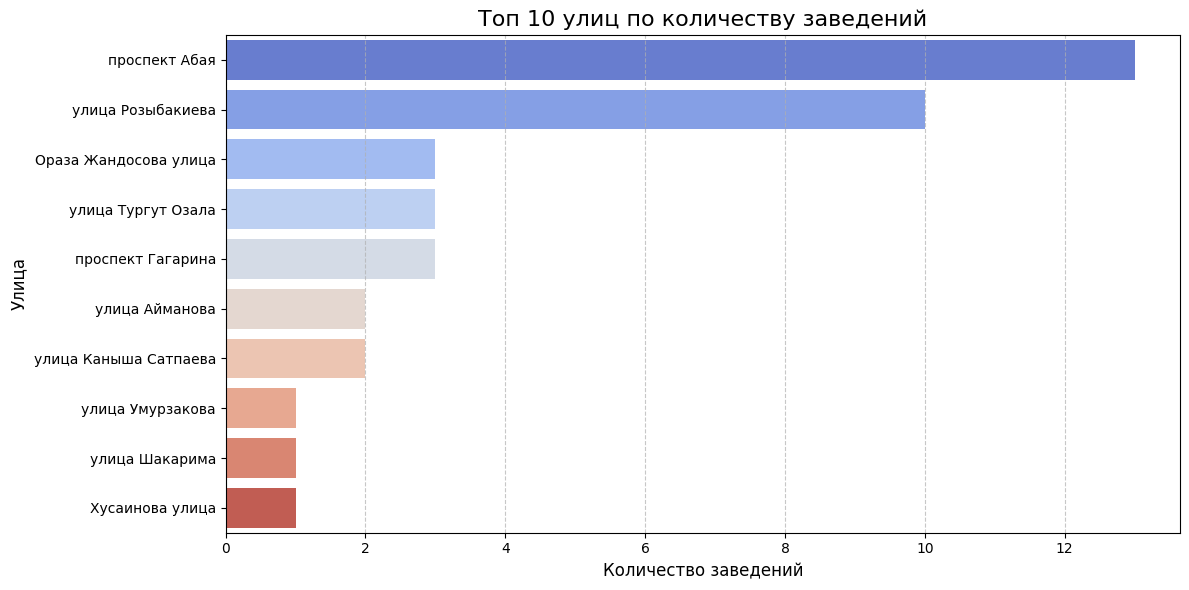

In [23]:
df['street'] = df['address_name'].str.extract(r'^(.*?),')

top_streets = df['street'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_streets.values, y=top_streets.index, hue=top_streets.index, palette='coolwarm', legend=False)
plt.title('Топ 10 улиц по количеству заведений', fontsize=16)
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('Улица', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


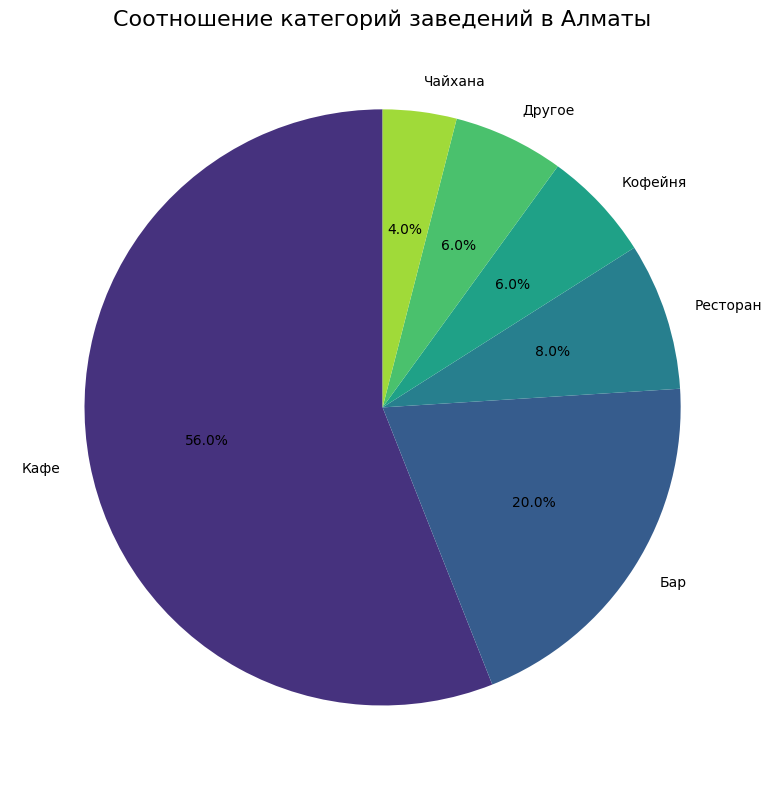

In [24]:
plt.figure(figsize=(8, 8))
df['category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(df['category'].unique())),
    startangle=90
)
plt.title('Соотношение категорий заведений в Алматы', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

In [25]:
df.to_csv('almaty_cafes_final.csv', index=False)
print("Данные сохранены!")
print(f"Всего заведений: {df.shape[0]}")
print(f"Топ улица: {df['street'].value_counts().index[0]}")
print(f"Самая популярная категория: {df['category'].value_counts().index[0]}")

Данные сохранены!
Всего заведений: 50
Топ улица: проспект Абая
Самая популярная категория: Кафе


## Выводы

1. Всего проанализировано 50 заведений в центре Алматы

2. Самая популярная категория — кафе (56%), что говорит о высоком спросе
   на casual dining среди жителей города

3. Проспект Абая лидирует по количеству заведений — это объясняется
   высокой проходимостью и центральным расположением

4. Бары занимают второе место (20%) — неожиданно высокий показатель
   для данного района

5. Чайханы представлены минимально (4%), хотя это традиционный
   формат для Казахстана
   